# Archive Evolution Guidance Test

This notebook compares three evolution-guidance variants on the same prompt:

- online evolution guidance
- archive-based evolution guidance
- archive-based evolution guidance with bad-sample repulsion

It reuses the repo's `evo_steering_playground.py` helpers so behavior stays aligned with the script.

## Colab-style flow (same spirit as evo_steering_playground)

1. Run the next cell to auto-detect Colab/local runtime, clone if needed, and checkout branch.
2. Run the install + sync cells.
3. Run the rest of the notebook normally.

These setup cells are safe to rerun.

In [16]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/khoing-ml/Fk-Diffusion-Steering.git"
BRANCH = "evov1"  # change this if you want to test a different branch
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_DIR = Path("/content/Fk-Diffusion-Steering")
else:
    # Prefer current workspace repo if we're already inside it.
    cwd = Path.cwd().resolve()
    if (cwd / ".git").exists() and (cwd / "text_to_image").exists():
        REPO_DIR = cwd
    elif (cwd.parent / ".git").exists() and (cwd.parent / "text_to_image").exists():
        REPO_DIR = cwd.parent
    else:
        REPO_DIR = cwd / "Fk-Diffusion-Steering"

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    print(f"Repo already exists at {REPO_DIR}")

subprocess.run(["git", "fetch", "--all", "--prune"], cwd=REPO_DIR, check=True)

# Be resilient if BRANCH is missing remotely: fallback to current branch, then main.
remote_ref = f"origin/{BRANCH}"
ls_remote = subprocess.run(
    ["git", "ls-remote", "--heads", "origin", BRANCH],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
    check=False,
)
if ls_remote.stdout.strip():
    subprocess.run(["git", "checkout", "-B", BRANCH, remote_ref], cwd=REPO_DIR, check=True)
else:
    print(f"Remote branch '{BRANCH}' not found. Falling back to existing checkout.")
    fallback = subprocess.run(
        ["git", "rev-parse", "--abbrev-ref", "HEAD"],
        cwd=REPO_DIR,
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if fallback == "HEAD" or not fallback:
        fallback = "main"
    subprocess.run(["git", "checkout", fallback], cwd=REPO_DIR, check=True)
    BRANCH = fallback

try:
    subprocess.run(["git", "pull", "--ff-only", "origin", BRANCH], cwd=REPO_DIR, check=True)
except subprocess.CalledProcessError as exc:
    print(f"Warning: git pull failed: {exc}")

os.chdir(REPO_DIR)
print(f"IN_COLAB = {IN_COLAB}")
print(f"cwd = {Path.cwd()}")
print(f"branch = {BRANCH}")

Repo already exists at /content/Fk-Diffusion-Steering
IN_COLAB = True
cwd = /content/Fk-Diffusion-Steering
branch = evov1


In [17]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
print("Installed repo requirements.")

Installed repo requirements.


In [18]:
import subprocess

subprocess.run(["git", "fetch", "origin", BRANCH], check=False)
subprocess.run(["git", "checkout", BRANCH], check=True)
subprocess.run(["git", "pull", "--ff-only", "origin", BRANCH], check=False)
print(f"Synced branch: {BRANCH}")

Synced branch: evov1


In [19]:
from __future__ import annotations

import json
import os
import sys
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display


DEFAULT_REPO_ROOTS = [
    Path(os.environ.get("FKD_REPO_ROOT", "/content/Fk-Diffusion-Steering")),
    Path.cwd(),
]


def find_repo_root(start_paths: list[Path] | None = None) -> Path:
    start_paths = DEFAULT_REPO_ROOTS if start_paths is None else start_paths
    for start in start_paths:
        start = start.resolve()
        for candidate in [start, *start.parents]:
            if (candidate / "text_to_image" / "fkd_diffusers").exists():
                return candidate
    raise FileNotFoundError("Could not find repo root from current working directory.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
TEXT_TO_IMAGE_ROOT = REPO_ROOT / "text_to_image"
FKD_ROOT = TEXT_TO_IMAGE_ROOT / "fkd_diffusers"

for path in [REPO_ROOT, TEXT_TO_IMAGE_ROOT, FKD_ROOT]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"TEXT_TO_IMAGE_ROOT = {TEXT_TO_IMAGE_ROOT}")

REPO_ROOT = /content/Fk-Diffusion-Steering
TEXT_TO_IMAGE_ROOT = /content/Fk-Diffusion-Steering/text_to_image


In [20]:
import csv
import shlex
import subprocess
import sys
from pathlib import Path

SCRIPT_PATH = TEXT_TO_IMAGE_ROOT / "evo_steering_playground.py"
if not SCRIPT_PATH.exists():
    SCRIPT_PATH = REPO_ROOT / "evo_steering_playground.py"

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Could not find evo_steering_playground.py at {TEXT_TO_IMAGE_ROOT} or {REPO_ROOT}")

print(f"CLI script: {SCRIPT_PATH}")

def run_playground_cli(*, output_dir: Path, seeds: list[int], extra_args: list[str]) -> tuple[Path, list[dict]]:
    output_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--model-name", MODEL_NAME,
        "--prompt", PROMPT,
        "--modes", "evolution",
        "--num-particles", str(NUM_PARTICLES),
        "--time-steps", str(TIME_STEPS),
        "--lmbda", str(LMBDA),
        "--svgd-step-size", str(SVGD_STEP_SIZE),
        "--guidance-frequency", str(GUIDANCE_FREQUENCY),
        "--resample-strategy", RESAMPLE_STRATEGY,
        "--evolution-resample-strategy", EVOLUTION_RESAMPLE_STRATEGY,
        "--guidance-reward-fn", GUIDANCE_REWARD_FN,
        "--fallback-reward-fn", FALLBACK_REWARD_FN,
        "--device", DEVICE,
        "--archive-size", str(ARCHIVE_SIZE),
        "--archive-good-quantile", str(ARCHIVE_GOOD_QUANTILE),
        "--archive-bad-quantile", str(ARCHIVE_BAD_QUANTILE),
        "--archive-burn-in-steps", str(ARCHIVE_BURN_IN_STEPS),
        "--min-good-anchors", str(MIN_GOOD_ANCHORS),
        "--min-bad-anchors", str(MIN_BAD_ANCHORS),
        "--seeds", ",".join(str(s) for s in seeds),
        "--output-dir", str(output_dir),
        "--auto-fix-deps",
    ] + extra_args

    print("CLI:")
    print(" ".join(shlex.quote(c) for c in cmd))
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)

    summary_csv = output_dir / "scores_summary.csv"
    rows: list[dict] = []
    with summary_csv.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        rows.extend(reader)
    return output_dir, rows

CLI script: /content/Fk-Diffusion-Steering/text_to_image/evo_steering_playground.py


In [21]:
MODEL_NAME = "stable-diffusion-2-1"
PROMPT = "a cinematic photo of a corgi astronaut on mars, ultra detailed"
DEVICE = "auto"

NUM_PARTICLES = 4
TIME_STEPS = 50
LMBDA = 2.0

GUIDANCE_REWARD_FN = "ImageReward"
FALLBACK_REWARD_FN = "Clip-Score"

SVGD_STEP_SIZE = 0.12
GUIDANCE_FREQUENCY = 5

RESAMPLE_STRATEGY = "multinomial"
EVOLUTION_RESAMPLE_STRATEGY = "none"

ARCHIVE_SIZE = 64
ARCHIVE_GOOD_QUANTILE = 0.75
ARCHIVE_BAD_QUANTILE = 0.25
ARCHIVE_BURN_IN_STEPS = 3
MIN_GOOD_ANCHORS = 8
MIN_BAD_ANCHORS = 8

SINGLE_SEED = 7
SWEEP_SEEDS = [1, 2, 3, 4, 5]

EXPERIMENT_ROOT = TEXT_TO_IMAGE_ROOT / "output" / f"archive_cli_notebook_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)

VARIANTS = [
    {
        "label": "online_evolution",
        "extra_args": [
            "--bad-guidance-strength", "0.0",
            "--min-bad-anchors", "0",
        ],
    },
    {
        "label": "archive_evolution",
        "extra_args": [
            "--use-anchor-archive",
            "--bad-guidance-strength", "0.0",
            "--min-bad-anchors", "0",
        ],
    },
    {
        "label": "archive_contrastive",
        "extra_args": [
            "--use-anchor-archive",
            "--bad-guidance-strength", "0.30",
            "--min-bad-anchors", str(MIN_BAD_ANCHORS),
        ],
    },
]

print(json.dumps({
    "model": MODEL_NAME,
    "prompt": PROMPT,
    "device": DEVICE,
    "reward_fn": GUIDANCE_REWARD_FN,
    "single_seed": SINGLE_SEED,
    "sweep_seeds": SWEEP_SEEDS,
    "experiment_root": str(EXPERIMENT_ROOT),
}, indent=2))

{
  "model": "stable-diffusion-2-1",
  "prompt": "a cinematic photo of a corgi astronaut on mars, ultra detailed",
  "device": "auto",
  "reward_fn": "ImageReward",
  "single_seed": 7,
  "sweep_seeds": [
    1,
    2,
    3,
    4,
    5
  ],
  "experiment_root": "/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818"
}


In [22]:
single_seed_outputs = []

for variant in VARIANTS:
    out_dir = EXPERIMENT_ROOT / f"single_{variant['label']}"
    _, summary_rows = run_playground_cli(
        output_dir=out_dir,
        seeds=[SINGLE_SEED],
        extra_args=variant["extra_args"],
    )
    row = dict(summary_rows[0])
    row["label"] = variant["label"]
    row["output_dir"] = str(out_dir)
    single_seed_outputs.append(row)

single_seed_outputs

CLI:
/usr/bin/python3 /content/Fk-Diffusion-Steering/text_to_image/evo_steering_playground.py --model-name stable-diffusion-2-1 --prompt 'a cinematic photo of a corgi astronaut on mars, ultra detailed' --modes evolution --num-particles 4 --time-steps 50 --lmbda 2.0 --svgd-step-size 0.12 --guidance-frequency 5 --resample-strategy multinomial --evolution-resample-strategy none --guidance-reward-fn ImageReward --fallback-reward-fn Clip-Score --device auto --archive-size 64 --archive-good-quantile 0.75 --archive-bad-quantile 0.25 --archive-burn-in-steps 3 --min-good-anchors 8 --min-bad-anchors 8 --seeds 7 --output-dir /content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/single_online_evolution --auto-fix-deps --bad-guidance-strength 0.0 --min-bad-anchors 0
CLI:
/usr/bin/python3 /content/Fk-Diffusion-Steering/text_to_image/evo_steering_playground.py --model-name stable-diffusion-2-1 --prompt 'a cinematic photo of a corgi astronaut on mars, ultra detailed'

[{'mode': 'evolution',
  'resample_strategy': 'none',
  'svgd_step_size': '0.12',
  'guidance_frequency': '5',
  'use_anchor_archive': 'False',
  'n_seeds': '1',
  'mean_of_mean': '0.158203125',
  'std_of_mean': '0.0',
  'mean_of_best': '0.158203125',
  'label': 'online_evolution',
  'output_dir': '/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/single_online_evolution'},
 {'mode': 'evolution',
  'resample_strategy': 'none',
  'svgd_step_size': '0.12',
  'guidance_frequency': '5',
  'use_anchor_archive': 'True',
  'n_seeds': '1',
  'mean_of_mean': '0.158203125',
  'std_of_mean': '0.0',
  'mean_of_best': '0.158203125',
  'label': 'archive_evolution',
  'output_dir': '/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/single_archive_evolution'},
 {'mode': 'evolution',
  'resample_strategy': 'none',
  'svgd_step_size': '0.12',
  'guidance_frequency': '5',
  'use_anchor_archive': 'True',
  'n_seeds': '1',
  'mea

online_evolution: mean=0.1582, best_mean=0.1582, archive=False


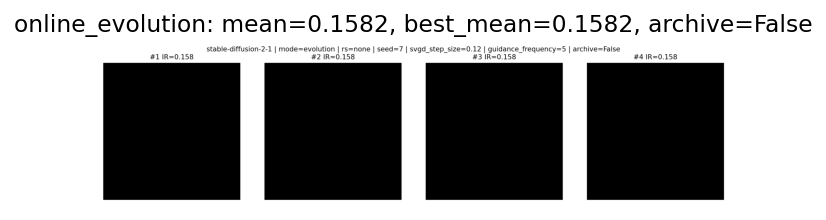

archive_evolution: mean=0.1582, best_mean=0.1582, archive=True


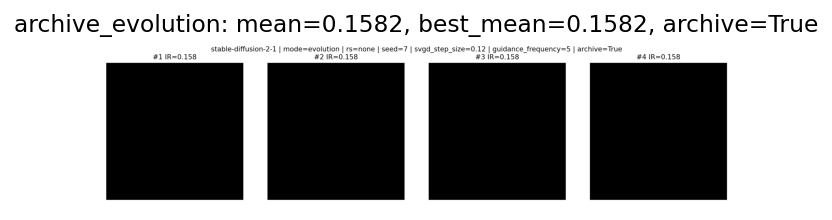

archive_contrastive: mean=0.1582, best_mean=0.1582, archive=True


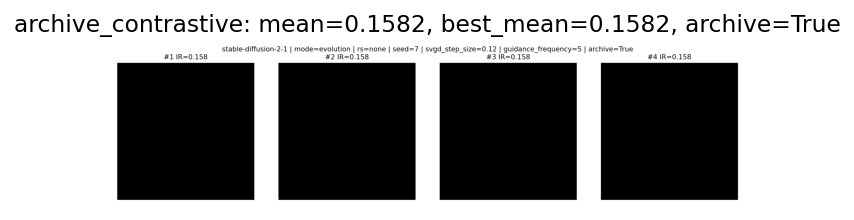

In [23]:
from PIL import Image

def display_variant_image(output_dir: Path, *, title: str):
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}")
        return

    image_path = pngs[0]
    im = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(6, 6), dpi=140)
    plt.imshow(im)
    plt.title(title)
    plt.axis("off")
    plt.show()

for row in single_seed_outputs:
    summary_text = (
        f"{row['label']}: mean={float(row['mean_of_mean']):.4f}, "
        f"best_mean={float(row['mean_of_best']):.4f}, "
        f"archive={row['use_anchor_archive']}"
    )
    print(summary_text)
    display_variant_image(Path(row["output_dir"]), title=summary_text)

## Single-seed comparison

This cell runs each variant on the same seed so you can inspect the images directly.

In [ ]:
sweep_outputs = []

for variant in VARIANTS:
    out_dir = EXPERIMENT_ROOT / f"sweep_{variant['label']}"
    _, summary_rows = run_playground_cli(
        output_dir=out_dir,
        seeds=SWEEP_SEEDS,
        extra_args=variant["extra_args"],
    )
    row = dict(summary_rows[0])
    row["label"] = variant["label"]
    row["output_dir"] = str(out_dir)
    sweep_outputs.append(row)

sweep_outputs

CLI:
/usr/bin/python3 /content/Fk-Diffusion-Steering/text_to_image/evo_steering_playground.py --model-name stable-diffusion-2-1 --prompt 'a cinematic photo of a corgi astronaut on mars, ultra detailed' --modes evolution --num-particles 4 --time-steps 50 --lmbda 2.0 --svgd-step-size 0.12 --guidance-frequency 5 --resample-strategy multinomial --evolution-resample-strategy none --guidance-reward-fn ImageReward --fallback-reward-fn Clip-Score --device auto --archive-size 64 --archive-good-quantile 0.75 --archive-bad-quantile 0.25 --archive-burn-in-steps 3 --min-good-anchors 8 --min-bad-anchors 8 --seeds 1,2,3,4,5 --output-dir /content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/sweep_online_evolution --auto-fix-deps --bad-guidance-strength 0.0 --min-bad-anchors 0
CLI:
/usr/bin/python3 /content/Fk-Diffusion-Steering/text_to_image/evo_steering_playground.py --model-name stable-diffusion-2-1 --prompt 'a cinematic photo of a corgi astronaut on mars, ultra de

[{'mode': 'evolution',
  'resample_strategy': 'none',
  'svgd_step_size': '0.12',
  'guidance_frequency': '5',
  'use_anchor_archive': 'False',
  'n_seeds': '5',
  'mean_of_mean': '0.158203125',
  'std_of_mean': '0.0',
  'mean_of_best': '0.158203125',
  'label': 'online_evolution',
  'output_dir': '/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/sweep_online_evolution'},
 {'mode': 'evolution',
  'resample_strategy': 'none',
  'svgd_step_size': '0.12',
  'guidance_frequency': '5',
  'use_anchor_archive': 'True',
  'n_seeds': '5',
  'mean_of_mean': '0.158203125',
  'std_of_mean': '0.0',
  'mean_of_best': '0.158203125',
  'label': 'archive_evolution',
  'output_dir': '/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/sweep_archive_evolution'},
 {'mode': 'evolution',
  'resample_strategy': 'none',
  'svgd_step_size': '0.12',
  'guidance_frequency': '5',
  'use_anchor_archive': 'True',
  'n_seeds': '5',
  'mean_

## Multi-seed sweep

This is the quickest way to see whether archive guidance is more stable than online guidance.

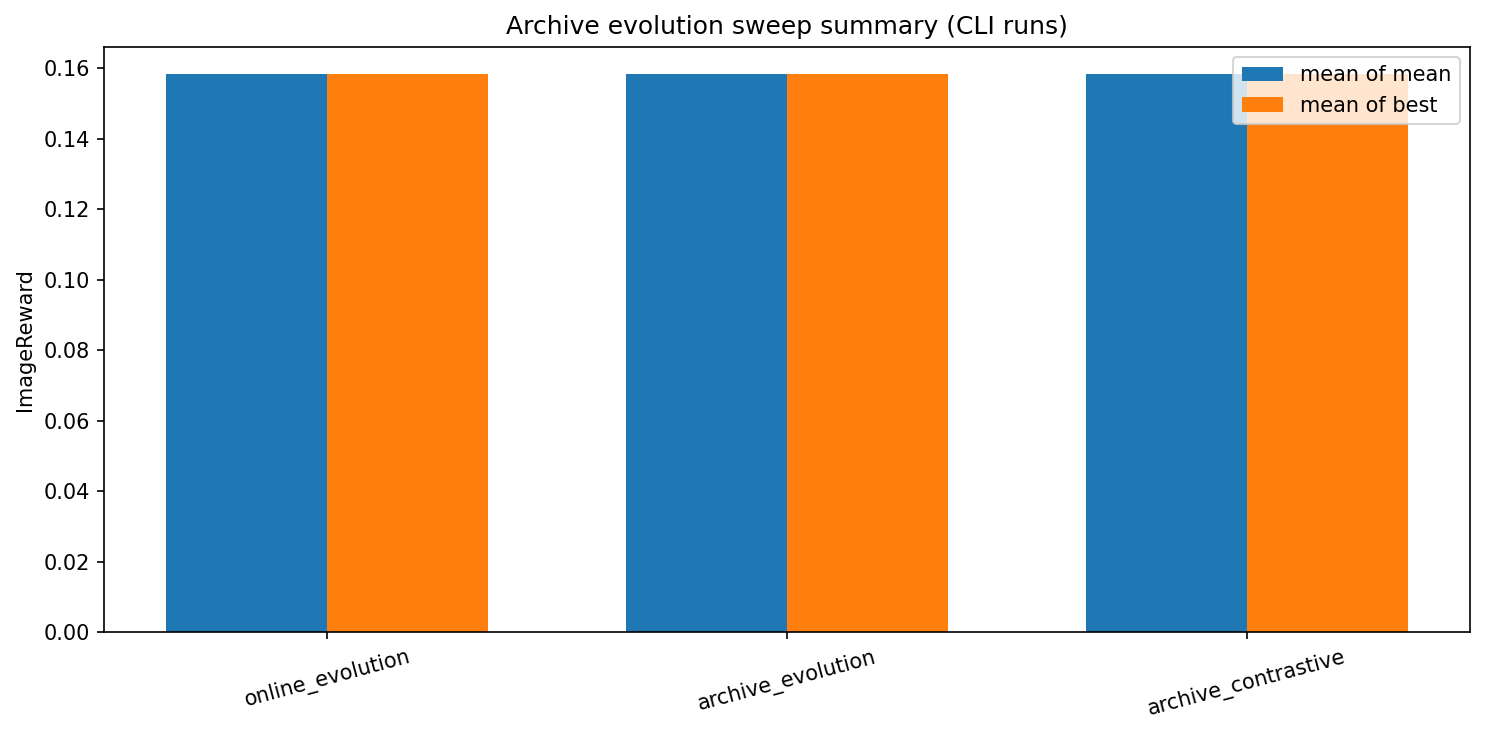

In [ ]:
labels = [row["label"] for row in sweep_outputs]
mean_of_mean = [float(row["mean_of_mean"]) for row in sweep_outputs]
std_of_mean = [float(row["std_of_mean"]) for row in sweep_outputs]
mean_of_best = [float(row["mean_of_best"]) for row in sweep_outputs]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.bar(x - width / 2, mean_of_mean, width, yerr=std_of_mean, label="mean of mean")
ax.bar(x + width / 2, mean_of_best, width, label="mean of best")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel(GUIDANCE_REWARD_FN)
ax.set_title("Archive evolution sweep summary (CLI runs)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
for row in sweep_outputs:
    print(
        f"{row['label']}: n={row['n_seeds']}, "
        f"mean_of_mean={float(row['mean_of_mean']):.4f}, "
        f"std_of_mean={float(row['std_of_mean']):.4f}, "
        f"mean_of_best={float(row['mean_of_best']):.4f}, "
        f"output_dir={row['output_dir']}"
    )

online_evolution: n=5, mean_of_mean=0.1582, std_of_mean=0.0000, mean_of_best=0.1582, output_dir=/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/sweep_online_evolution
archive_evolution: n=5, mean_of_mean=0.1582, std_of_mean=0.0000, mean_of_best=0.1582, output_dir=/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/sweep_archive_evolution
archive_contrastive: n=5, mean_of_mean=0.1582, std_of_mean=0.0000, mean_of_best=0.1582, output_dir=/content/Fk-Diffusion-Steering/text_to_image/output/archive_cli_notebook_20260329-144818/sweep_archive_contrastive


## Suggested follow-up experiments

Try changing one knob at a time:

- `GUIDANCE_FREQUENCY`
- `ARCHIVE_BURN_IN_STEPS`
- `ARCHIVE_SIZE`
- `ARCHIVE_GOOD_QUANTILE` and `ARCHIVE_BAD_QUANTILE`
- `bad_guidance_strength` in `VARIANTS["archive_contrastive"]`
- `EVOLUTION_RESAMPLE_STRATEGY`

If the archive version still collapses, the next thing to add is archive diagnostics per step: unique-anchor count, reward histogram, and pairwise diversity.